## Medical Insurance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how Medical insurance cost billed to the beneficiary is affected by other variables such as age, sex, bmi, number of children, smoking status and region.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset
- The data consists of 7 column and 1338 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/insurance.csv')

#### Show Top 5 Records

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Shape of the dataset

In [6]:
df.shape

(1338, 7)

### 2.2 Dataset information

- age: Age of primary beneficiary (int)
- sex: Gender of beneficiary (male, female)
- bmi: Body Mass Index, a measure of body fat based on height and weight (float)
- children: Number of children covered by health insurance (int)
- smoker: Smoking status of the beneficiary (yes, no)
- region: Residential region in the US (northeast, northwest, southeast, southwest)
- charges: Medical insurance cost billed to the beneficiary (float)

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [7]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [11]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [12]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


### 3.4 Checking the number of unique values of each column

In [13]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

### 3.5 Check statistics of data set

In [14]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


#### Insight
- Medical charges show high variability (mean ≈ 13.3k, std ≈ 12.1k) indicating diverse risk levels.
- Charges are right-skewed (median ≈ 9.4k vs mean ≈ 13.3k) due to high-cost outliers.
- Maximum charges (≈ 63.7k) are almost 4x higher than 75th percentile (≈ 16.6k) → strong outliers present.
- Average BMI is ≈ 30.7, indicating most individuals fall in the overweight/obese category.
- Age ranges from 18 to 64 (mean ≈ 39), showing a well-distributed dataset.
- Most individuals have ≤ 2 children (75th percentile = 2), limiting its impact on cost prediction.
- Median charges (≈ 9.4k) are significantly lower than max (≈ 63.7k), confirming cost concentration among few individuals.

### 3.7 Exploring Data

In [15]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
print("Categories in 'sex' variable:     ",end=" " )
print(df['sex'].unique())

print("Categories in 'smoker' variable:  ",end=" ")
print(df['smoker'].unique())

print("Categories in'region' variable:",end=" " )
print(df['region'].unique())

Categories in 'sex' variable:      ['female' 'male']
Categories in 'smoker' variable:   ['yes' 'no']
Categories in'region' variable: ['southwest' 'southeast' 'northwest' 'northeast']


In [18]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 4 numerical features : ['age', 'bmi', 'children', 'charges']

We have 3 categorical features : ['sex', 'smoker', 'region']


In [19]:
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


### 4. Exploring Data ( Visualization )
#### 4.1 Visualising the data for key insights 

#### 4.1.1 Distribution Plots

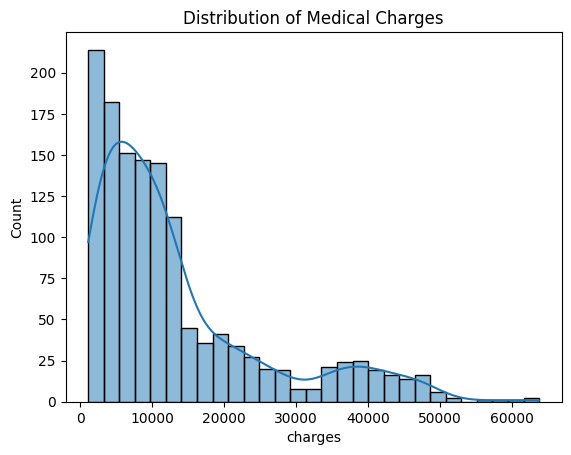

In [21]:
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

#####  Insights
- Female students tend to perform well then male students.

#### 4.4 Feature Wise Visualization

#### UNIVARIATE ANALYSIS 

#### 4.4.1 Age Distribution

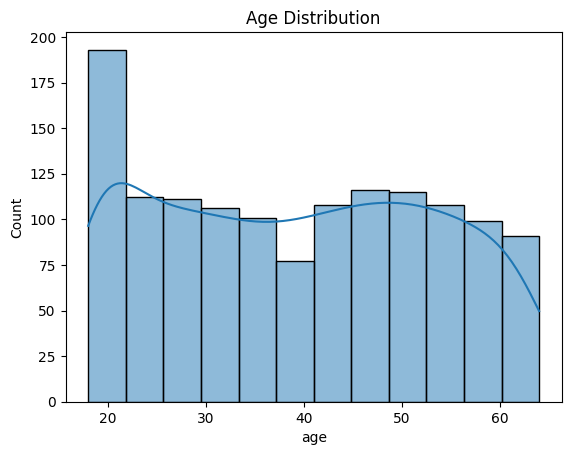

In [27]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

#### Insights 
- Age is fairly evenly distributed between 18 and 64

#### 4.4.2 BMI Distribution

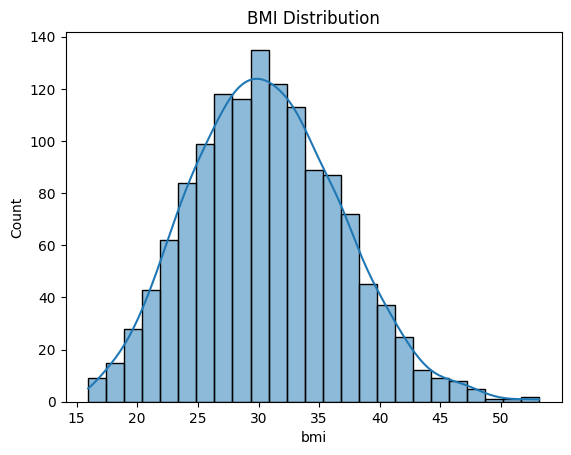

In [29]:
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

#### Insights:
- Majority of individuals have BMI around 30 (overweight range)

#### 4.4.3 Children Distribution

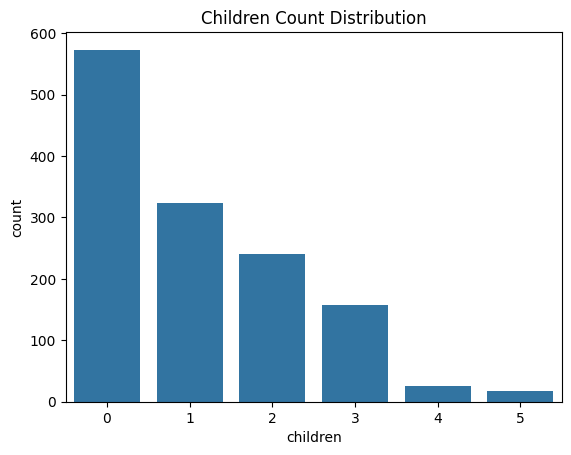

In [30]:
sns.countplot(x='children', data=df)
plt.title("Children Count Distribution")
plt.show()

#### Insights:

- Most individuals have 0–2 children

#### 4.4.4 Smoker Count

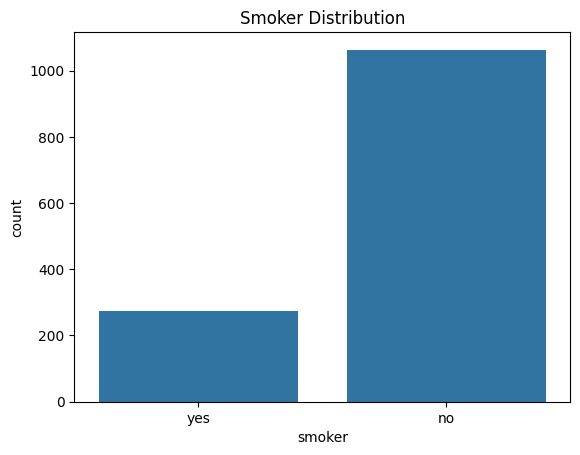

In [32]:
sns.countplot(x='smoker', data=df)
plt.title("Smoker Distribution")
plt.show()

#### Insights:
- Majority are non-smokers, but smokers drive higher costs

#### BIVARIATE ANALYSIS

Charges vs Smoker

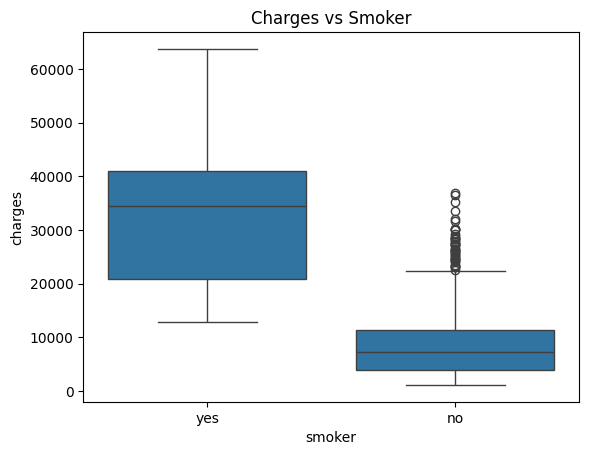

In [34]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges vs Smoker")
plt.show()

Insight:

Smokers have significantly higher charges

In [ ]:
BMI vs Charges

In [ ]:
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("BMI vs Charges")
plt.show()

In [ ]:
High BMI + smoker → highest charges

In [ ]:
Age vs Charges

In [ ]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

In [ ]:
Insight:

Charges increase with age

In [ ]:
 Children vs Charges

In [ ]:
sns.boxplot(x='children', y='charges', data=df)
plt.title("Children vs Charges")
plt.show()

In [ ]:
Insight:

Children have weak impact on charges

In [ ]:
MULTIVARIATE ANALYSIS

In [ ]:
Pairplot

In [ ]:
sns.pairplot(df, hue='smoker')
plt.show()

In [ ]:
Insight:

Clear separation of high charges among smokers

In [ ]:
Correlation Heatmap

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
Insight:

Charges strongly correlate with BMI and age

### 5. Conclusions
Key Insights:

- Charges are highly skewed (mean ≈ 13.3k vs median ≈ 9.4k)
- Smokers incur significantly higher medical costs
- BMI (~30.7 avg) indicates overweight population impacting costs
- Age positively correlates with charges
- Children have limited influence on cost
- High-cost outliers exist (max ≈ 63.7k)